# Baseline Model Tests
Here we run a number of baseline models,including

* DummyClassifier's (For baseline metrics)
* LogisticRegression's
* DecisionTree's
* RandomForest's
* LGBMClassifier's
* XGBClassifier's

We also play around with balancing through imbalance-learn's SMOTE and RandomOverSampling. This is slightly less baseline, but we will include them in this notebook anyway.

Here is a summary of our metrics:

* Recall with scikit-learn's `recall_score`
    * Given by $$R=\frac{T_p}{T_p+F_n},$$ where $T_p$ is the number of true positives and $F_n$ is the number of false negatives.
    * Helps detect False Negatives (especially important for tornadoes). A Recall score of 1 is ideal; 0 is the worst.
* Precision with scikit-learn's `precision_score`
    * Given by $$P=\frac{T_p}{T_p+F_p},$$ where $T_p$ is the number of true positives and $F_p$ is the number of false positives.
    * Helps detect False Positives. A Precision score of 1 is ideal; 0 is the worst. 
    * While false positives are less than ideal, we will put more weight on false negatives (recall score) since this our goal is predicting tornado occurrence.
* F2-score with scikit-learn's `fbeta_score`.
    *$$F2 =\frac{(1+2^2)(\mathrm{precision}\cdot \mathrm{recall})}{(2^2\mathrm{precision})+\mathrm{recall}}$$
    * Provides a single measure  both false positives and false negatives.
    * Useful for overall summary of detection performance.
* Average Precision with scikit-learn's `average_precision_score`
    * Threshold independent
    * Area under the Precision-Recall curve (PR-AUC) given by plotting precision versus recall at various thresholds.
    * A weighted mean of the precision across with weights being differences in recall values across successive threshold values.
    * Informative metric for unbalanced target columns such as ours.
* ROC-AUC with scikit-learn's `roc_auc_score`
    * Area under the Receiver Operating Characteristic curve (ROC-AUC)given by plotting true positive rates over false positive rates at various thresholds.
    * Gives a sense on if the model is learning how to differentiate between conditions leading to tornadic and non-tornadic events even if the `Average Precision` (see below) score is low. 
    * Threshold independent.
    * Can appear overly optimistic in cases of severe class imbalance (like ours). Hence, we treat it as a secondary indicator of whether the model is learning to rank conditions leading to tornadic events versus non-tornadic events.


In order of importance our key metrics are:
1. Average Precision (PR-AUC)
2. F2-Score
3. Recall
4. ROC-AUC
5. Precision

---

**ASSUMPTION:** All validation and testing thresholds computed for models in this project are chosen as the threshold that yields the best F2 score for the training data. 

---

## 1. Our Target - A Brief Summary



Each row in the dataset represents a **station-hour observation**  with:
- Meteorological readings from a weather station.
- Tornado Occurrence. True if tornado began within val_radius =75 kilometers away and `time_window`=3  hours after station observation.
- Station information (id number, lat,lon coordinates, elevation,...)

Our prediction target is a Boolean variable:
> `TORNADO_OCCURRENCE ∈ {0, 1}` — whether a tornado was active near the station within `time_window=3` hours after observation and within 75 kilometers..


## 2. Getting the Data

### 2.1 Imports

In [1]:
## Setup
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
#import seaborn as sns
import datetime as dt
import notebook_file_utilities.auto_add_project_root as proroot
import pathlib
import sklearn

# Models
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import KFold, StratifiedKFold, TimeSeriesSplit

# imbalance learning
from imblearn.over_sampling import SMOTE,RandomOverSampler
from imblearn.pipeline import Pipeline as ImbPipeline

# sklearn preprocessing
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (OneHotEncoder, 
                                    FunctionTransformer, 
                                    StandardScaler)


# Calibration
from sklearn.calibration import CalibratedClassifierCV


# For reading in modules from src and reading/saving files
project_root = proroot.auto_add_project_root()

import src.modeling.model_summary as mds
import src.modeling.train_test_split as tts
# Pipeline
#from src.pipeline.preprocessing import preprocessing
#from src.pipeline.feature_engineering import pre_train_test_split_FE
#from src.pipeline.drop_cols import (
#    pre_split_drop,
#    post_split_drop
#)
sklearn.set_config(transform_output="default")




### 2.2 Read in Data

In [2]:
final_data_path = pathlib.Path('data/final_cleaned/final.csv')
data = pd.read_csv(project_root/final_data_path)



### 2.3 Train-Validation-Test Splits

We split our data into a training set, validation set, and test set as follows:

* Training set: 2000-01-01 00:00:00 to 2017-12-31 22:53:00 
* Validation set: 2017-12-31 23:52:00 to 2019-12-31 23:52:00
* Test set: 2019-12-31 23:53:00 to 2021-12-31 23:53:00

* Train tornado rate: 0.1480%
* Validation tornado rate: 0.2180%
* Test tornado rate: 0.1316%


**Justification**:
Since predicting tornadoes is a temporal problem, we are cautious of temporal leakage. Therefore, we split chronologically with training years preceding validation years and validation years preceding test years. 

Our specific chronological intervals were chosen so that:

1. The combined training and validation data forms 91.0% of all data and also a roughly even number of tornado occurrences:
    * Training + Validation tornado rate: 0.1547%
    * Test tornado rate: 0.1316%

2. The training data forms 90.5% of the total training and validation data. In this case the relative tornado rates are slightly skewed:
    * Train tornado rate: 0.1480%
    * Validation tornado rate: 0.2180%
    

**Justification**
* Basing our train-val-test splittings on years is representative of real-world model deployment.
* The differing tornado rates here are representative of temporal distribution shifts-- a feature of tornadoes (and weather events in general) that we should capture.


The code below performs the training-validation-test split outlined above and saves it to the subfolder `train_val_test_splits` located in the folder `data`.


In [3]:


print("="*20, "Train_Test Split","="*20)
train_data,test_data = tts.temporal_train_test_split(data, date_column='DATE', test_years=2)
test_data['DATE'] = pd.to_datetime(test_data['DATE'])
test_data.to_csv(project_root/pathlib.Path('data/train_val_test_splits/test_data.csv'),index=False)



# Create validation data
print("="*20, "Train_Validation Split","="*20)

train_data,val_data = tts.temporal_train_test_split(train_data, date_column='DATE', test_years=2)
train_data['DATE'] = pd.to_datetime(train_data['DATE']) 
val_data['DATE'] = pd.to_datetime(val_data['DATE']) 
train_data.to_csv(project_root/pathlib.Path('data/train_val_test_splits/train_data.csv'),index=False)
val_data.to_csv(project_root/pathlib.Path('data/train_val_test_splits/val_data.csv'),index=False)

y_train =train_data['TORNADO_OCCURRENCE']
X_train = train_data.drop(columns = ['TORNADO_OCCURRENCE'])
y_val = val_data['TORNADO_OCCURRENCE']
X_val=val_data.drop(columns = ['TORNADO_OCCURRENCE'])



==================== Train_Test Split ====================
Train period: 2000-01-01 00:00:00 to 2019-12-31 23:52:00
Test period: 2019-12-31 23:53:00 to 2021-12-31 23:53:00
Train size: 563,033 (91.0%)
Test size: 55,453 (9.0%)
Train tornado rate: 0.1547%
Test tornado rate: 0.1316%
==================== Train_Validation Split ====================
Train period: 2000-01-01 00:00:00 to 2017-12-31 22:53:00
Test period: 2017-12-31 23:52:00 to 2019-12-31 23:52:00
Train size: 509,364 (90.5%)
Test size: 53,669 (9.5%)
Train tornado rate: 0.1480%
Test tornado rate: 0.2180%


In [4]:
# Print actual numbers
print("Class distribution:")
print(f"Train: {y_train.value_counts().to_dict()}")
print(f"  Tornado rate: {y_train.mean():.4%}")
print(f"Val: {y_val.value_counts().to_dict()}")
print(f"  Tornado rate: {y_val.mean():.4%}")


Class distribution:
Train: {False: 508610, True: 754}
  Tornado rate: 0.1480%
Val: {False: 53552, True: 117}
  Tornado rate: 0.2180%


### 2.3 Cross Validation Strategy:

Our cross validation strategy consists of using our custom splitter `YearlyTemporalWindowSplit()`, which can be found in [src/modeling/train_test_split.py](../src/modeling/train_test_split.py). `YearlyTemporalWindowSplit()` creates our cv folds as follows:

Fold 1:  Train [2000]      → Val [2001-2002]
Fold 2:  Train [2000-2003] → Val [2003-2004]
...
Fold 8: Train [2000-2015] → Val [2016-2017]

**Justification**

This expanding window strategy emulates realistic model deployment where we would train on all historical data and predict on the next time period. By validating on individual years sequentially, we:

1. Test model robustness across different temporal distributions (each year has unique weather patterns and tornado frequencies)
2. Prevent data leakage by maintaining strict chronological ordering
3. Evaluate performance across multiple time periods rather than a single validation window, giving more reliable estimates of generalization

This is particularly important given the temporal distribution shifts we observe in tornado occurrence rates across years (e.g., validation year 2018-2019 had 0.218% tornado rate vs training's 0.148%). This approach stops at 2017 to preserve our held-out validation set (2018-2019) and test set (2020-2021) for final model selection and evaluation.

In [5]:
expanding_cv=tts.YearlyTemporalWindowSplit(start_year =2002,end_year = 2017, val_window_size=2)


tts.print_cv_split_check(expanding_cv, train_data, date_column='DATE',target_column='TORNADO_OCCURRENCE')

CROSS-VALIDATION SPLIT VERIFICATION

Total number of folds: 8
Dataset size: 509,364 samples
Overall tornado rate: 0.1480%

--------------------------------------------------------------------------------

Fold 1:
  Train: 2000-01-01 to 2001-12-31
         51,971 samples, 62 tornadoes (0.1193%)
  Val:   2002-01-01 to 2003-12-31
         52,908 samples, 45 tornadoes (0.0851%)

Fold 2:
  Train: 2000-01-01 to 2003-12-31
         104,879 samples, 107 tornadoes (0.1020%)
  Val:   2004-01-01 to 2005-12-31
         63,925 samples, 83 tornadoes (0.1298%)

Fold 3:
  Train: 2000-01-01 to 2005-12-31
         168,804 samples, 190 tornadoes (0.1126%)
  Val:   2006-01-01 to 2007-12-31
         56,231 samples, 74 tornadoes (0.1316%)

Fold 4:
  Train: 2000-01-01 to 2007-12-31
         225,035 samples, 264 tornadoes (0.1173%)
  Val:   2008-01-01 to 2009-12-31
         61,197 samples, 139 tornadoes (0.2271%)

Fold 5:
  Train: 2000-01-01 to 2009-12-31
         286,232 samples, 403 tornadoes (0.1408%)
  Va

,fold,train_size,val_size,train_rate,val_rate,train_tornadoes,val_tornadoes
0,1,51971,52908,0.001193,0.000851,62,45
1,2,104879,63925,0.001020,0.001298,107,83
2,3,168804,56231,0.001126,0.001316,190,74
3,4,225035,61197,0.001173,0.002271,264,139
4,5,286232,61496,0.001408,0.001252,403,77
5,6,347728,57390,0.001380,0.002544,480,146
6,7,405118,50038,0.001545,0.001459,626,73
7,8,455156,54208,0.001536,0.001015,699,55


### 2.4 Observations on Train, Expanding CV folds, and Validation Data

Each of our 8 CV folds has a validation set of 2 years, reflecting our main validation set.

1. Across our 8 folds,there are two validation sets with more tornadoes than other years, namely folds 4 and 6 (2008-2010 and 2012-2013). In comparison, our main validation set has 117 tornadoes.
2. Majority of the folds (all except fold 4 and fold 6) have less than 100 tornadoes in their validation sets.
3. Even though our CV will see folds 4 and 6, our model may struggle to generalize to our validation data. 

**Takeaway:** 

* In the process of creating our model, it is important to remember that our validation set has a abnormal number of tornado occurences. It is incredibly likely that we will see overfitting from training data to validation data.
* In hyperparameter tuning, we should keep in mind that our CV folds 4 and 6 are also abnormal in the number of tornadoes in their validation sets. 






## 3. Preprocessing 

Our preprocessing pipeline uses scikit-learn's ColumnTransformer to handle different feature types appropriately. First, we categorize features into five groups based on their data type and required transformations:

|Category|Features|Count|
|--------|--------|-----|
|Numeric|WND_direction_angle, WND_speed_rate, CIG_ceiling_height, VIS_distance, TMP_air_temperature, DEW_dew_point, SLP_sea_level_pressure|7|
|Binary| (coded)CIG_cavok_code, VIS_variability_code|2|
|Binary| (flag)WND_direction_angle_variable_wind_direction_flag|1|
|Nominal|WND_type_code|1|
|Datetime|DATE|1|


**Transformation Pipelines**

1. numeric_feature_pipeline:

    * Imputes missing values using feature-wise median
    * Standardizes features to mean=0, std=1


2. binary_pipeline:

    * Encodes categorical binary codes to numeric 
        * N -> 0, Y -> 1 for CAVOK
        * N -> 0, V -> 1 for visibility variability
    * Assigns -1 to any missing or unexpected values


3. nominal_pipeline:

    * One-hot encodes wind type code
    * Drops the original category and creates the new encoded category with same name.



4. passthrough_features:

    * Preserves 'WND_direction_angle_variable_wind_direction_flag' feature without transformation


5. drop_features:

    * Removes DATE column (temporal information captured via rolling window features)

6.  All other features are dropped. For future work, if one would like to extend to tornado detection to any location (not just Oklahoma City), we would want to keep spatial features. Here we do not.


The following code creates the preprocessing pipeline.

In [6]:
#=========================================================================
# FEATURE CATEGORIES FOR COLUMN TRANSFORMER PREPROCESSING
#=========================================================================

turn_to_binary_features = [
    'CIG_cavok_code', 'VIS_variability_code'
]

nominal_features = [
    'WND_type_code', 
]

numeric_features = [
    'WND_direction_angle', 'WND_speed_rate',
    'CIG_ceiling_height', 'VIS_distance',
    'TMP_air_temperature', 'DEW_dew_point',
    'SLP_sea_level_pressure'
]

binary_features = ['WND_direction_angle_variable_wind_direction_flag']

datetime_features =['DATE']


#=========================================================================
# BINARY ENCODING FUNCTION
#=========================================================================


def encode_binary(X):
    """Map binary codes to 1, 0. Any missing or unexpected values get mapped
    to -1"""
    mappings = {
        'CIG_cavok_code': {'N': 0, 'Y': 1},
        'VIS_variability_code': {'N': 0, 'V': 1}
    }
    X_copy = X.copy()
    for col in X_copy.columns:
        if col in mappings:
            X_copy[col] = X_copy[col].map(mappings[col]).fillna(-1).astype(int)
    return X_copy


#=========================================================================
# PIPELINES FOR PREPROCESSING COLUMN TRANSFORMER
#=========================================================================

numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median',missing_values=np.nan)),
    ('scale', StandardScaler())
])


turn_to_binary_pipeline = Pipeline(
    [
        ('binary', FunctionTransformer(encode_binary))
    ]
    )

nominal_features_pipeline = Pipeline(
    [
        ('nominal', OneHotEncoder(drop='first', handle_unknown='ignore',sparse_output=False))
    ]
)

#=========================================================================
# PREPROCESSING COLUMN TRANSFORMER
#=========================================================================

preprocessor = ColumnTransformer(
    transformers=[
        ('numeric_feature_pipeline', numeric_pipeline, numeric_features),
        ('binary_pipeline', turn_to_binary_pipeline, turn_to_binary_features),
        ('nominal_pipeline', nominal_features_pipeline, nominal_features),
        ('passthrough_features','passthrough', binary_features),
        ('drop_features','drop', datetime_features)
    ]
)








## 4. Baseline Models

Here we train a number of baseline models and validate their performance. The models that do best will be selected and studied in the next modeling stage.

---

**An Important Note:** 
From here on out, model fitting, model metrics, and model plots will be attained through the custom `ModuleUtilities` class. See [module_summary.py](../src/modeling/model_summary.py) for the code making up this class.

---

### 4.1 Dummy Model

Here we train a scikit-learn DummyClassifier with strategy = `stratefied` (important as our label is highly unbalanced). The results here are our true baseline for how well subsequent models compare to random guessing. 

In [7]:
# Dummy Classifier for baseline performance

dummy_models={}

dummy_models['dummy_stratified'] = Pipeline(
    [
    ('preprocessing',preprocessor),
    ('classifier', DummyClassifier(strategy ='stratified'))
    ]
    )  



In [8]:
# fit models
dummy_models_object = mds.ModelingUtilities(dict_of_models=dummy_models)
dummy_models_object.fit_models(X_train,y_train)
dummy_models_object.save_training_probabilities(X_train)

# save/get training best f2 threshold
dummy_models_object.get_train_best_fbeta_thresholds(y_train,beta=2)



# Step 3: Now evaluate on test with locked threshold
dummy_models_object.save_test_probabilities(X_val, testing_type='validation')
dummy_models_metrics = dummy_models_object.get_metrics(
    y_data=y_val,
    beta=2,
    use_train_threshold=True,
    return_dataframe=True
)

 
# save
save_to = project_root/pathlib.Path('results/baseline_model_metrics/dummy_metrics.csv')
dummy_models_metrics.to_csv(save_to)

print('='*80)

print('METRICS')
display(dummy_models_metrics)


Fitting model dummy_stratified
METRICS


,Model,Parameters,validation_Threshold,validation_avg_precision,validation_F2,validation_Recall,validation_Precision,validation_roc_auc,validation_brier_score
0,dummy_stratified,"{'memory': None, 'steps': [('preprocessing', C...",0.0,0.00218,0.010806,1.0,0.00218,0.499281,0.003615


#### 4.1.1 Metrics Summary

Based on the results from our dummy models, our models in the phases below should satisfy the following:

|Metric|Desired Score|
|-------|------------|
|    average_precision   |      $0.00218$ |
|   f2    |$\geq 0.010806$|
|    roc_auc   |     $\geq .5$    |




---

### 4.2. Classical ML Models (No Calibration)

Here we train:

* LogisticRegression (L2 Regularization)
* LogisticRegression (L1 Regularization)
* DecisionTree

In [9]:
# ============================================================================
# PHASE 1: 
# ============================================================================


baselines_classical = {}

# -----------------------------------------------------------------------------
# 1. LOGISTIC REGRESSION (L2 Regularization) 
# -----------------------------------------------------------------------------
baselines_classical['LogReg_L2'] = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        C=1.0,                    # Inverse regularization strength
        penalty='l2',
        solver='saga',
        max_iter=100,
        random_state=42,
           
    ))
])
# -----------------------------------------------------------------------------
# 2. LOGISTIC REGRESSION (L1 Regularization)
# -----------------------------------------------------------------------------
baselines_classical['LogReg_L1'] = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        C=1.0,
        penalty='l1',
        solver='saga',            # Required for L1
        max_iter=100,
        random_state=42,
        
    ))
])

# -----------------------------------------------------------------------------
# 3. DECISION TREE (Single Tree)
# -----------------------------------------------------------------------------
baselines_classical['DecisionTree'] = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(
        max_depth=10,
        min_samples_split=50,
        min_samples_leaf=20,
        random_state=42,
        class_weight=None
    ))
])



In [10]:
# fit models
classical_models_object = mds.ModelingUtilities(dict_of_models=baselines_classical)
classical_models_object.fit_models(X_train,y_train)
classical_models_object.save_training_probabilities(X_train)

# save/get training best f2 threshold
classical_models_object.get_train_best_fbeta_thresholds(y_train,beta=2)


# Step 3: Now evaluate on test with locked threshold
classical_models_object.save_test_probabilities(X_val, testing_type='validation')
classical_models_metrics = classical_models_object.get_metrics(
    y_data=y_val,
    beta=2,
    use_train_threshold=True,
    return_dataframe=True
)


# save
save_to = project_root/pathlib.Path('results/baseline_model_metrics/classical_metrics.csv')
classical_models_metrics.to_csv(save_to)

print('='*80)

print('METRICS')
display(classical_models_metrics)




Fitting model LogReg_L2


/opt/anaconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Fitting model LogReg_L1
Fitting model DecisionTree
METRICS


,Model,Parameters,validation_Threshold,validation_avg_precision,validation_F2,validation_Recall,validation_Precision,validation_roc_auc,validation_brier_score
0,LogReg_L2,"{'memory': None, 'steps': [('preprocessor', Co...",0.013434,0.013075,0.055287,0.136752,0.016343,0.891068,0.002172
1,LogReg_L1,"{'memory': None, 'steps': [('preprocessor', Co...",0.013562,0.013055,0.052083,0.128205,0.015432,0.891176,0.002172
2,DecisionTree,"{'memory': None, 'steps': [('preprocessor', Co...",0.068966,0.010702,0.012970,0.017094,0.006601,0.692706,0.002315


#### 4.2.1 Metric Summary

From here we see that our models are well calibrated based on their Brier Scores.
|Model| average_precision|
|--------|-------|
|LogReg_L2|   $\approx 6.7\times$ better|
|LogReg_L1|  $\approx 6.7\times$ better|
|DecisionTree|   $\approx 4.9\times$ better|


#### 4.2.2 Confusion Matrices

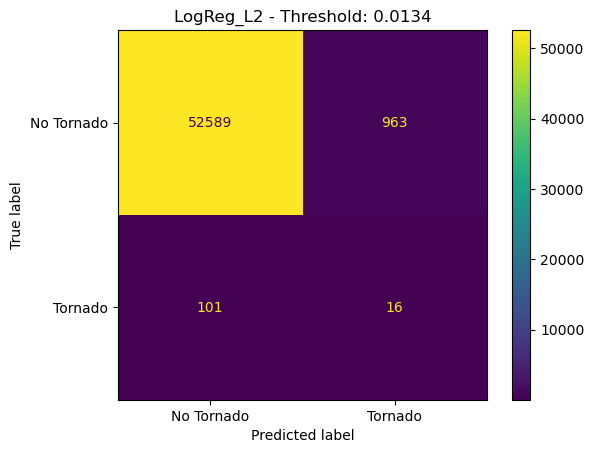

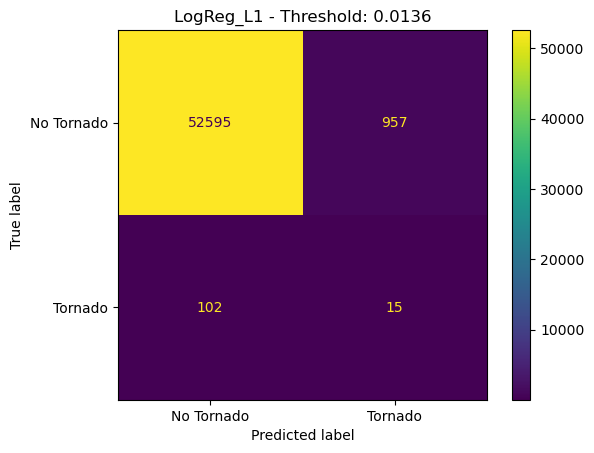

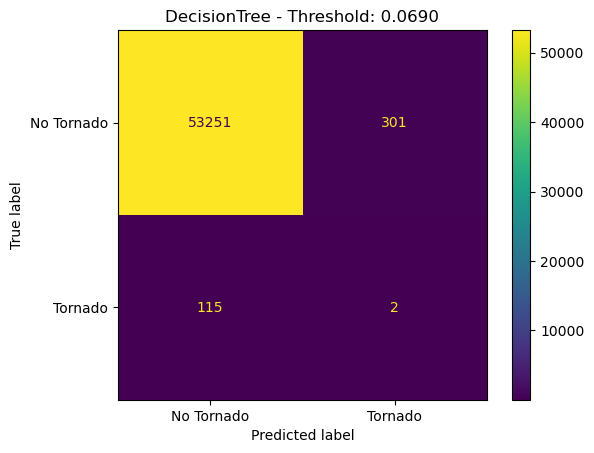

In [11]:
save_to_dir=project_root/pathlib.Path('results/baseline_model_figures/confusion_matrix')
classical_models_object.create_confusion_matrix(y_val=y_val,use_train_threshold=True,save_to_dir=save_to_dir)

#### 4.2.3 PR Curves

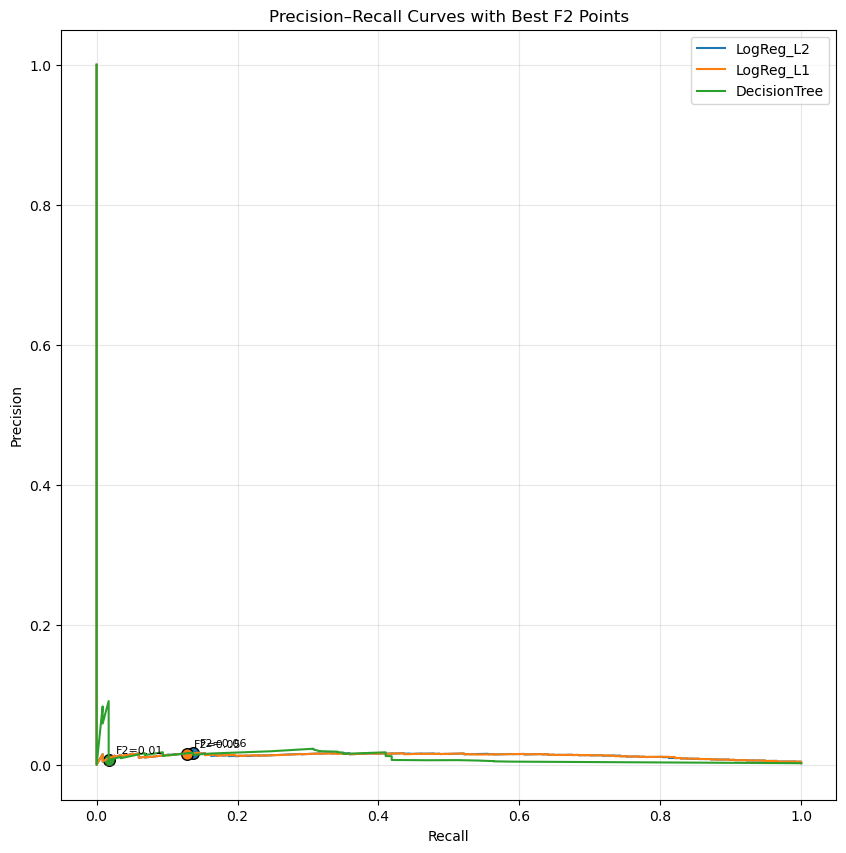

In [12]:
save_to=project_root/pathlib.Path('results/baseline_model_figures/prec_rec_curves/baseline_classical.png')
classical_models_object.plt_precision_recall_curve(y_val=y_val,beta=2,use_train_threshold=True,save_to=save_to)


---

### 4.4 Classical ML Models with Class Balancing and Calibration

Here we train:

* LogisticRegression (Balanced and Calibrated)
* DecisionTree (Balanced and Calibrated)
* RandomForest (Balanced and Calibrated)

All calibrations here and subsequent ones are done with scikit-learn's CalibratedClassifierCV.

In [13]:

# ============================================================================
# PHASE 2: CLASSICAL ML WITH CLASS BALANCING AND CALIBRATION
# ============================================================================



baselines_balanced = {}

# ============================================================================
# 1. DECISION TREE (Balanced)
# ============================================================================
baselines_balanced['DecisionTree_Balanced'] = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(
        max_depth=10,
        min_samples_split=50,
        min_samples_leaf=20,
        random_state=42,
        class_weight='balanced'
    ))
])


# ============================================================================
# 2. RANDOM FOREST (Balanced)
# ============================================================================
baselines_balanced['RandomForest_Balanced'] = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        min_samples_split=50,
        min_samples_leaf=20,
        max_features='sqrt',
        random_state=42,
        class_weight='balanced',
        n_jobs=-1
    ))
])


#--------------------CALIBRATION-------------------------------------------------

for name,model in baselines_balanced.items():
    calibrated_model = CalibratedClassifierCV(
    estimator=model,  
    method='isotonic',        
    cv=expanding_cv                   
    )

    baselines_balanced[name]=calibrated_model
    
    


In [14]:
# fit models
balanced_models_object = mds.ModelingUtilities(dict_of_models=baselines_balanced)
balanced_models_object.fit_models(X_train,y_train)
balanced_models_object.save_training_probabilities(X_train)

# save/get training best f2 threshold
balanced_models_object.get_train_best_fbeta_thresholds(y_train,beta=2)


# Step 3: Now evaluate on test with locked threshold
balanced_models_object.save_test_probabilities(X_val, testing_type='validation')
balanced_models_metrics = balanced_models_object.get_metrics(
    y_data=y_val,
    beta=2,
    use_train_threshold=True,
    return_dataframe=True
)

 
# save
save_to = project_root/pathlib.Path('results/baseline_model_metrics/balanced_metrics.csv')
balanced_models_metrics.to_csv(save_to)

print('='*80)

print('METRICS')
display(balanced_models_metrics)





Fitting model DecisionTree_Balanced
Fitting model RandomForest_Balanced
METRICS


,Model,Parameters,validation_Threshold,validation_avg_precision,validation_F2,validation_Recall,validation_Precision,validation_roc_auc,validation_brier_score
0,DecisionTree_Balanced,{'cv': YearlyTemporalWindowSplit(end_year=2017...,0.014448,0.017315,0.027586,0.034188,0.015564,0.813653,0.002164
1,RandomForest_Balanced,{'cv': YearlyTemporalWindowSplit(end_year=2017...,0.026917,0.016624,0.014684,0.017094,0.009390,0.890378,0.002161


#### 4.4.1 Metrics Summary


From here we see that our models are well calibrated based on their Brier Scores. 

|Model|  average_precision|
|--------|--------|
|LogReg_Balanced|   $\approx 6.5\times$ better|
|DecisionTree_Balanced|  $\approx 8.5\times$ better|
|RandomForest_Balanced|  $\approx 8\times$ better|


#### 4.4.2 Confusion Matrices

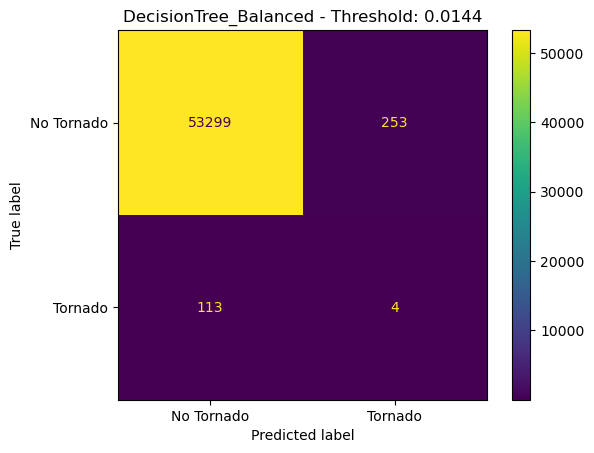

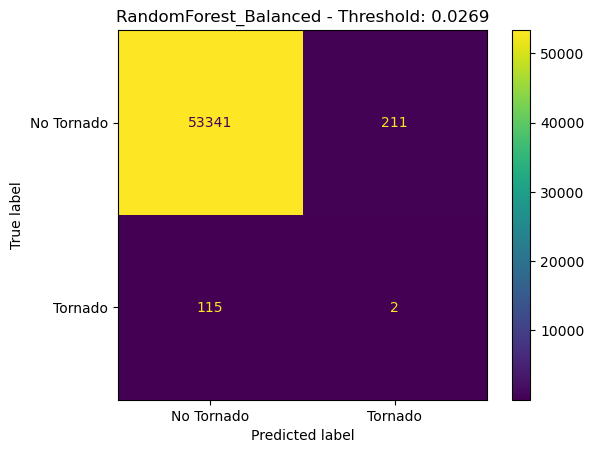

In [15]:
save_to_dir=project_root/pathlib.Path('results/baseline_model_figures/confusion_matrix')
balanced_models_object.create_confusion_matrix(y_val=y_val,use_train_threshold=True,save_to_dir=save_to_dir)



#### 4.4.3 PR Curves

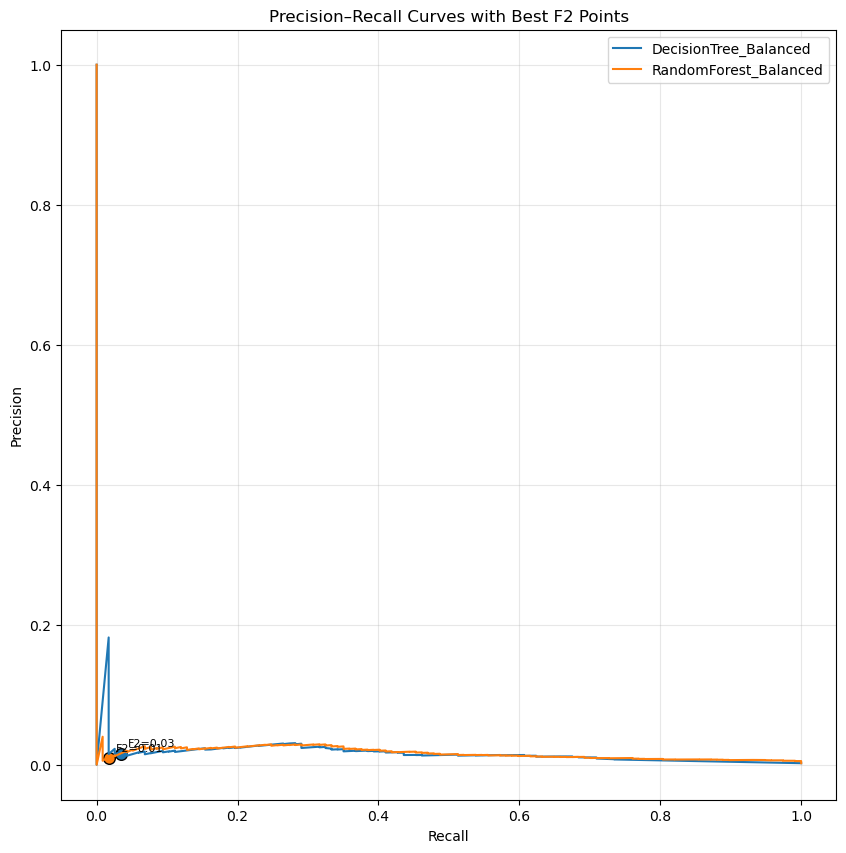

In [16]:
save_to=project_root/pathlib.Path('results/baseline_model_figures/prec_rec_curves/baseline_balanced.png')
balanced_models_object.plt_precision_recall_curve(y_val=y_val,beta=2,use_train_threshold=True,save_to=save_to)


---

### 4.5 Modern Tree Ensembles 

Here we train:

* XGBoostClassifier (Balanced and Calibrated) - low learning rate
* XGBoostClassifier (Balanced and Calibrated) - high learning rate 
* LightGBM_Positive_Weight (Balanced and Calibrated)
* LightGBM_Unbalanced_Flag (Balanced and Calibrated)

In [17]:
# ============================================================================
# PHASE 3: MODERN TREE ENSEMBLES (OPTIMIZED FOR IMBALANCE)
# ============================================================================
scale_pos =  (len(y_train) - y_train.sum()) / y_train.sum()


baselines_modern = {}

# -----------------------------------------------------------------------------
# 1. XGBOOST (Conservative - Low Learning Rate)
# -----------------------------------------------------------------------------
baselines_modern['XGBoost_Conservative'] = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(
        n_estimators=500,
        max_depth=6,
        learning_rate=0.01,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos,
        min_child_weight=5,
        gamma=0.1,
        random_state=42,
        eval_metric='aucpr'
    ))
])


# -----------------------------------------------------------------------------
# 2. XGBOOST (Aggressive - Higher Learning Rate)
# -----------------------------------------------------------------------------
baselines_modern['XGBoost_Aggressive'] = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(
        n_estimators=200,
        max_depth=8,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos,
        min_child_weight=1,
        gamma=0,
        random_state=42,
        eval_metric='logloss'
    ))
])



#--------------------CALIBRATION-------------------------------------------------

for name,model in baselines_modern.items():
    calibrated_model = CalibratedClassifierCV(
    estimator=model,  
    method='isotonic',        
    cv=expanding_cv                   
    )

    baselines_modern[name]=calibrated_model





In [18]:
# fit models
modern_models_object = mds.ModelingUtilities(dict_of_models=baselines_modern)
modern_models_object.fit_models(X_train,y_train)
modern_models_object.save_training_probabilities(X_train)

# save/get training best f2 threshold
modern_models_object.get_train_best_fbeta_thresholds(y_train,beta=2)


# Step 3: Now evaluate on test with locked threshold
modern_models_object.save_test_probabilities(X_val, testing_type='validation')
modern_models_metrics = modern_models_object.get_metrics(
    y_data=y_val,
    beta=2,
    use_train_threshold=True,
    return_dataframe=True
)

 
# save
save_to = project_root/pathlib.Path('results/baseline_model_metrics/modern_metrics.csv')
modern_models_metrics.to_csv(save_to)

print('='*80)

print('METRICS')
display(modern_models_metrics)





Fitting model XGBoost_Conservative
Fitting model XGBoost_Aggressive
METRICS


,Model,Parameters,validation_Threshold,validation_avg_precision,validation_F2,validation_Recall,validation_Precision,validation_roc_auc,validation_brier_score
0,XGBoost_Conservative,{'cv': YearlyTemporalWindowSplit(end_year=2017...,0.028878,0.020201,0.035336,0.034188,0.040816,0.879479,0.002157
1,XGBoost_Aggressive,{'cv': YearlyTemporalWindowSplit(end_year=2017...,0.029236,0.018468,0.019493,0.017094,0.044444,0.852950,0.002161


#### 4.5.1 Metrics Summary
From here we see that our models are well calibrated based on their Brier Scores.

|Model| average_precision|
|--------|-------|
|XGBoost_Conservative|  $\approx 10\times$ better|
|XGBoost_Aggressive|   $\approx 9.5\times$ better|



#### 4.5.2 Confusion Matrices

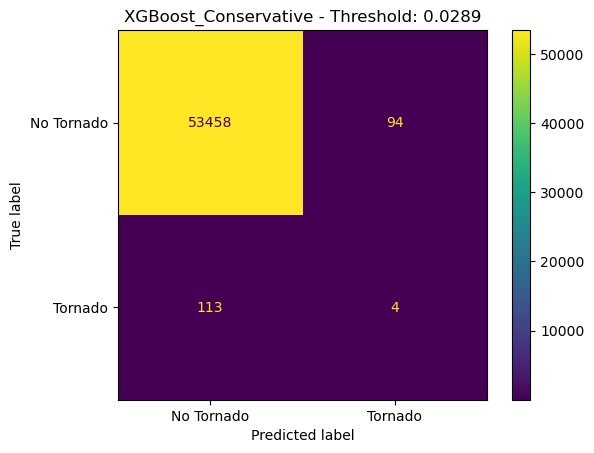

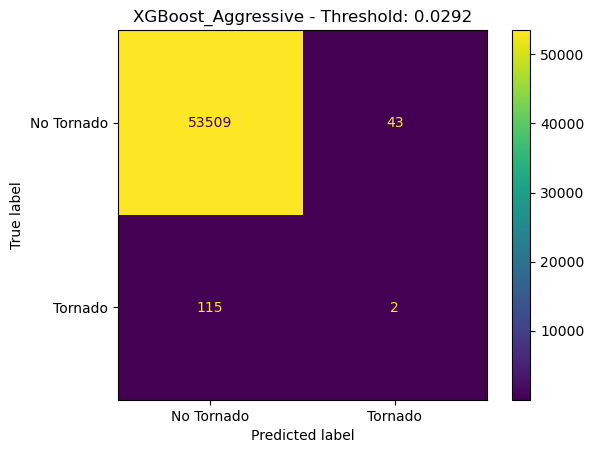

In [19]:
save_to_dir=project_root/pathlib.Path('results/baseline_model_figures/confusion_matrix')
modern_models_object.create_confusion_matrix(y_val=y_val,use_train_threshold=True,save_to_dir=save_to_dir)


#### 4.5.3 PR Curves

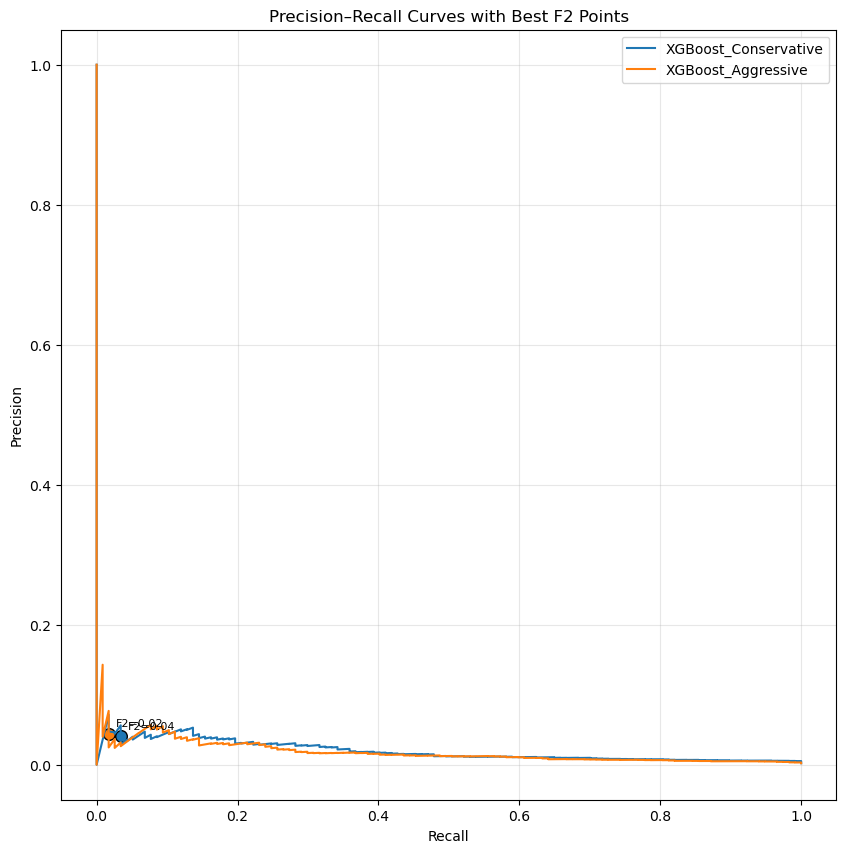

In [20]:

save_to=project_root/pathlib.Path('results/baseline_model_figures/prec_rec_curves/baseline_modern.png')
modern_models_object.plt_precision_recall_curve(y_val=y_val,beta=2,use_train_threshold=True,save_to=save_to)


---

### 4.6 RandomOverSampling

Here we train:

* RandomForest with RandomOverSampling (Calibrated)
* XGBoost with RandomOverSampling (Calibrated)


In [21]:

baselines_ROS = {}


# -----------------------------------------------------------------------------
# 1. RANDOM FOREST + ROS
# -----------------------------------------------------------------------------
baselines_ROS['RF_ROS'] = ImbPipeline([
    ('preprocessor', preprocessor),
    ('over_random', RandomOverSampler(
        random_state=42
    )),
    ('classifier', RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        min_samples_split=50,
        min_samples_leaf=20,
        random_state=42,
        n_jobs=-1
    ))
])
# -----------------------------------------------------------------------------
# 2. XGBOOST + ROS
# -----------------------------------------------------------------------------
baselines_ROS['XGBoost_ROS'] = ImbPipeline([
    ('preprocessor', preprocessor),
    ('over_random', RandomOverSampler(
        random_state=42
    )),
    ('classifier', XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric='logloss',
    ))
])


#--------------------CALIBRATION-------------------------------------------------

for name,model in baselines_ROS.items():
    calibrated_model = CalibratedClassifierCV(
    estimator=model,  
    method='isotonic',        
    cv=expanding_cv               
    )

    baselines_ROS[name]=calibrated_model



In [22]:
# fit models
ros_models_object = mds.ModelingUtilities(dict_of_models=baselines_ROS)
ros_models_object.fit_models(X_train,y_train)
ros_models_object.save_training_probabilities(X_train)

# save/get training best f2 threshold
ros_models_object.get_train_best_fbeta_thresholds(y_train,beta=2)


# Step 3: Now evaluate on test with locked threshold
ros_models_object.save_test_probabilities(X_val, testing_type='validation')
ros_models_metrics = ros_models_object.get_metrics(
    y_data=y_val,
    beta=2,
    use_train_threshold=True,
    return_dataframe=True
)

 
# save
save_to = project_root/pathlib.Path('results/baseline_model_metrics/ros_metrics.csv')
ros_models_metrics.to_csv(save_to)

print('='*80)

print('METRICS')
display(ros_models_metrics)





Fitting model RF_ROS
Fitting model XGBoost_ROS
METRICS


,Model,Parameters,validation_Threshold,validation_avg_precision,validation_F2,validation_Recall,validation_Precision,validation_roc_auc,validation_brier_score
0,RF_ROS,{'cv': YearlyTemporalWindowSplit(end_year=2017...,0.032078,0.018930,0.008772,0.008547,0.009804,0.883368,0.002160
1,XGBoost_ROS,{'cv': YearlyTemporalWindowSplit(end_year=2017...,0.020936,0.026379,0.103022,0.128205,0.057692,0.868135,0.002157


#### 4.6.1 Summary

From here we see that our models are well calibrated based on their Brier Scores. Moreover, here is how our phase 4 models stand in comparison with our dummy metrics:

|Model|  average_precision|
|--------|-------|
|RF_ROS| $\approx 9\times$ better|
|XGBoost_ROS|  $\approx 13\times$ better|


#### 4.6.2 Confusion Matrices

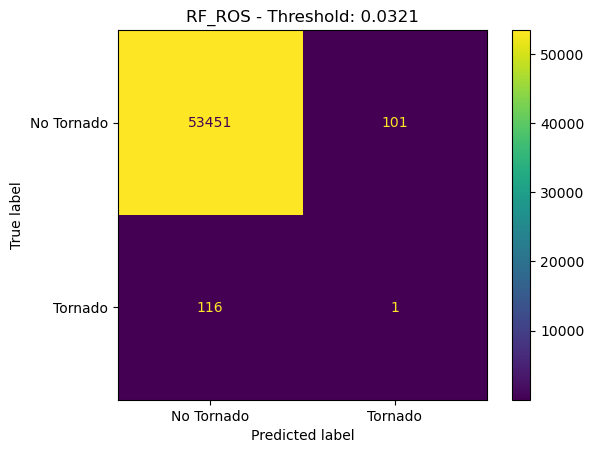

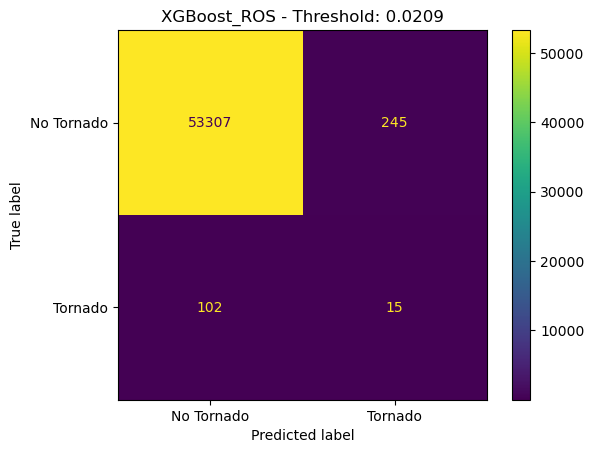

In [23]:
save_to_dir=project_root/pathlib.Path('results/baseline_model_figures/confusion_matrix')
ros_models_object.create_confusion_matrix(y_val=y_val,use_train_threshold=True,save_to_dir=save_to_dir)



#### 4.6.3 PR Curves

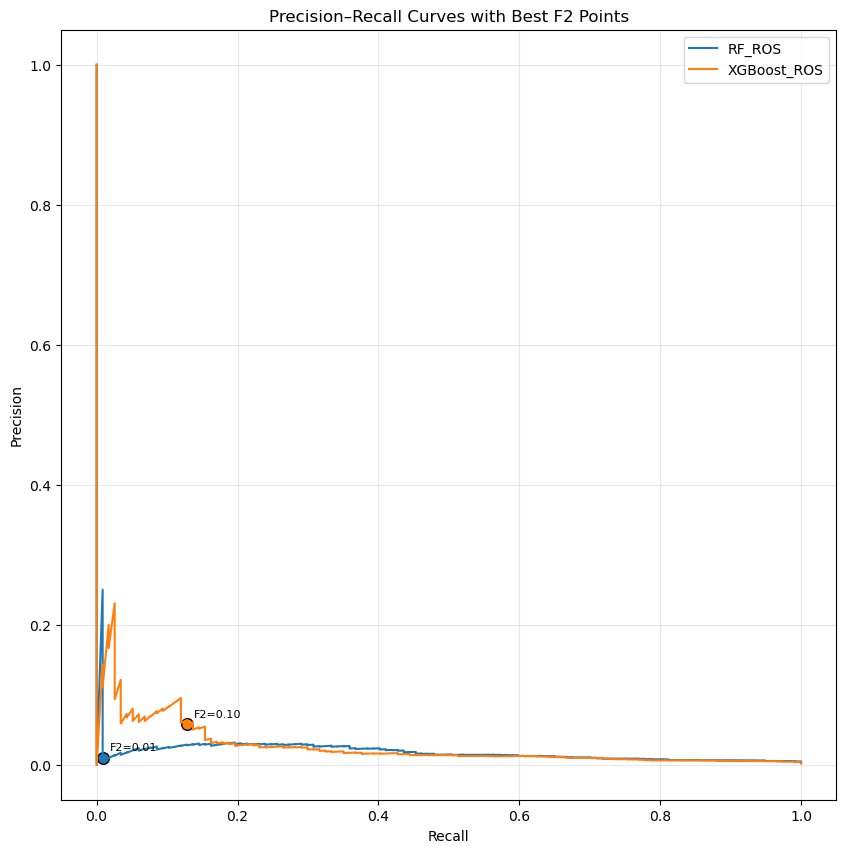

In [24]:
save_to=project_root/pathlib.Path('results/baseline_model_figures/prec_rec_curves/baseline_ros.png')
ros_models_object.plt_precision_recall_curve(y_val=y_val,beta=2,use_train_threshold=True,save_to=save_to)


---

### 4.7 SMOTE

Here we train:

* RandomForestClassifier with SMOTE (Calibrated)
* XGBoostClassifier with SMOTE (Calibrated)


In [25]:

baselines_smote = {}

# -----------------------------------------------------------------------------
# 1. RANDOM FOREST + SMOTE
# -----------------------------------------------------------------------------
baselines_smote['RF_SMOTE'] = ImbPipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE(
        sampling_strategy=0.3,
        k_neighbors=5,
        random_state=42
    )),
    ('classifier', RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        min_samples_split=50,
        min_samples_leaf=20,
        random_state=42,
        n_jobs=-1
    ))
])
# -----------------------------------------------------------------------------
# 2. XGBOOST + SMOTE 
# -----------------------------------------------------------------------------
baselines_smote['XGBoost_SMOTE'] = ImbPipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE(
        sampling_strategy=0.3,
        k_neighbors =5,
        random_state=42
    )),
    ('classifier', XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric='aucpr'
    ))
])


#--------------------CALIBRATION-------------------------------------------------

for name,model in baselines_smote.items():
    calibrated_model = CalibratedClassifierCV(
    estimator=model,  
    method='isotonic',        
    cv=expanding_cv                     
    )

    baselines_smote[name]=calibrated_model
    



In [26]:
# fit models
smote_models_object = mds.ModelingUtilities(dict_of_models=baselines_smote)
smote_models_object.fit_models(X_train,y_train)
smote_models_object.save_training_probabilities(X_train)

# save/get training best f2 threshold
smote_models_object.get_train_best_fbeta_thresholds(y_train,beta=2)


# Step 3: Now evaluate on test with locked threshold
smote_models_object.save_test_probabilities(X_val, testing_type='validation')
smote_models_metrics = smote_models_object.get_metrics(
    y_data=y_val,
    beta=2,
    use_train_threshold=True,
    return_dataframe=True
)

 
# save
save_to = project_root/pathlib.Path('results/baseline_model_metrics/smote_metrics.csv')
smote_models_metrics.to_csv(save_to)

print('='*80)

print('METRICS')
display(smote_models_metrics)




Fitting model RF_SMOTE
Fitting model XGBoost_SMOTE
METRICS


,Model,Parameters,validation_Threshold,validation_avg_precision,validation_F2,validation_Recall,validation_Precision,validation_roc_auc,validation_brier_score
0,RF_SMOTE,{'cv': YearlyTemporalWindowSplit(end_year=2017...,0.022391,0.021322,0.049226,0.059829,0.028807,0.906564,0.002157
1,XGBoost_SMOTE,{'cv': YearlyTemporalWindowSplit(end_year=2017...,0.020142,0.019554,0.074516,0.085470,0.049261,0.874139,0.002159


#### 4.7.1 Metrics Summary

From here we see that our models are well calibrated based on their Brier Scores. 

|Model| average_precision|
|--------|-------|
|RF_SMOTE|   $\approx 11\times$ better|
|XGBoost_SMOTE|   $\approx 9.5\times$ better|


#### 4.7.2 Confusion Matrices

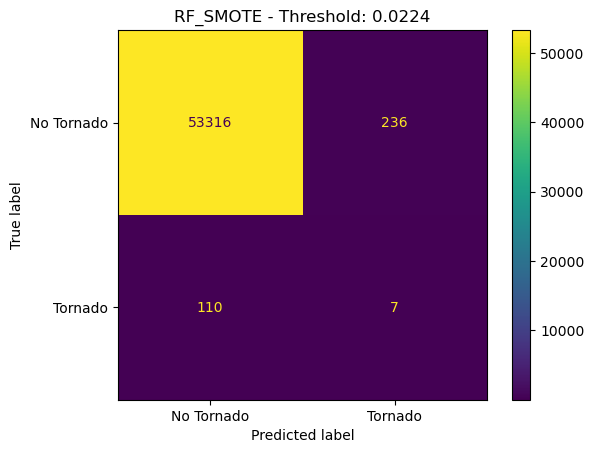

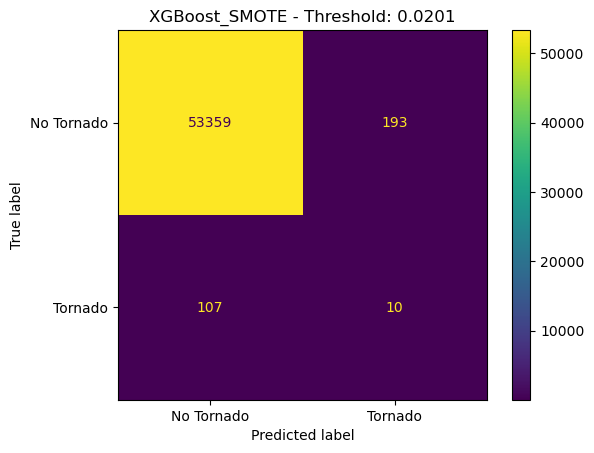

In [27]:

save_to_dir=project_root/pathlib.Path('results/baseline_model_figures/confusion_matrix')
smote_models_object.create_confusion_matrix(y_val=y_val,use_train_threshold=True,save_to_dir=save_to_dir)




#### 4.7.2 PR Curves

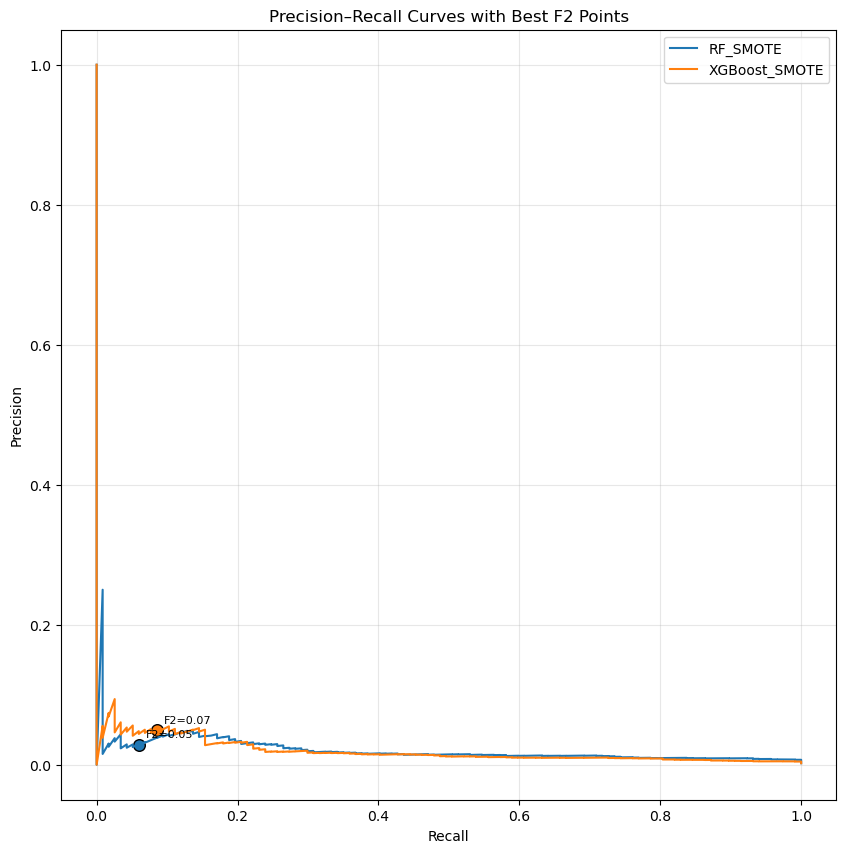

In [28]:

save_to=project_root/pathlib.Path('results/baseline_model_figures/prec_rec_curves/baseline_smote.png')
smote_models_object.plt_precision_recall_curve(y_val=y_val,beta=2,use_train_threshold=True,save_to=save_to)


---

## 5 Final Comparison

We concatenate all previous metric dataframes into a final combined data frame.

In [29]:
to_concat= [classical_models_metrics,
            balanced_models_metrics,
            modern_models_metrics,
            ros_models_metrics,
            smote_models_metrics]
best_threshold_metrics = pd.concat(to_concat,ignore_index=True)
save_to = project_root/pathlib.Path("results/baseline_model_metrics/final_combined.csv")
best_threshold_metrics.to_csv(save_to)

In [30]:
best_threshold_metrics.sort_values(by='validation_avg_precision',ascending=False)

,Model,Parameters,validation_Threshold,validation_avg_precision,validation_F2,validation_Recall,validation_Precision,validation_roc_auc,validation_brier_score
8,XGBoost_ROS,{'cv': YearlyTemporalWindowSplit(end_year=2017...,0.020936,0.026379,0.103022,0.128205,0.057692,0.868135,0.002157
9,RF_SMOTE,{'cv': YearlyTemporalWindowSplit(end_year=2017...,0.022391,0.021322,0.049226,0.059829,0.028807,0.906564,0.002157
5,XGBoost_Conservative,{'cv': YearlyTemporalWindowSplit(end_year=2017...,0.028878,0.020201,0.035336,0.034188,0.040816,0.879479,0.002157
10,XGBoost_SMOTE,{'cv': YearlyTemporalWindowSplit(end_year=2017...,0.020142,0.019554,0.074516,0.085470,0.049261,0.874139,0.002159
7,RF_ROS,{'cv': YearlyTemporalWindowSplit(end_year=2017...,0.032078,0.018930,0.008772,0.008547,0.009804,0.883368,0.002160
6,XGBoost_Aggressive,{'cv': YearlyTemporalWindowSplit(end_year=2017...,0.029236,0.018468,0.019493,0.017094,0.044444,0.852950,0.002161
3,DecisionTree_Balanced,{'cv': YearlyTemporalWindowSplit(end_year=2017...,0.014448,0.017315,0.027586,0.034188,0.015564,0.813653,0.002164
4,RandomForest_Balanced,{'cv': YearlyTemporalWindowSplit(end_year=2017...,0.026917,0.016624,0.014684,0.017094,0.009390,0.890378,0.002161
0,LogReg_L2,"{'memory': None, 'steps': [('preprocessor', Co...",0.013434,0.013075,0.055287,0.136752,0.016343,0.891068,0.002172
1,LogReg_L1,"{'memory': None, 'steps': [('preprocessor', Co...",0.013562,0.013055,0.052083,0.128205,0.015432,0.891176,0.002172


In [31]:
best_threshold_metrics.sort_values(by='validation_avg_precision',ascending=False)[['Model','validation_avg_precision','validation_roc_auc','validation_brier_score']]

,Model,validation_avg_precision,validation_roc_auc,validation_brier_score
8,XGBoost_ROS,0.026379,0.868135,0.002157
9,RF_SMOTE,0.021322,0.906564,0.002157
5,XGBoost_Conservative,0.020201,0.879479,0.002157
10,XGBoost_SMOTE,0.019554,0.874139,0.002159
7,RF_ROS,0.018930,0.883368,0.002160
6,XGBoost_Aggressive,0.018468,0.852950,0.002161
3,DecisionTree_Balanced,0.017315,0.813653,0.002164
4,RandomForest_Balanced,0.016624,0.890378,0.002161
0,LogReg_L2,0.013075,0.891068,0.002172
1,LogReg_L1,0.013055,0.891176,0.002172


## 6. Final Summary

Based on these results, we will work further with the model `XGBoost_ROS` and `RF_SMOTE`. Both of these have a comparatively high AP Score and high f2 scores at the best training threshold. Furthermore, the model's Brier Score is very low indicating probabilities for each are calibrated. 




### 6.1 Training vs. Validation metrics (Overfitting Test)

In [32]:
baselines_final ={}
baselines_final['XGBoost_ROS']= baselines_ROS['XGBoost_ROS']
baselines_final['RF_SMOTE']= baselines_smote['RF_SMOTE']

data_dict = {'train': {'X':X_train,'y':y_train},
            'validation':{'X':X_val,'y':y_val}}

mds.train_val_model_metrics_df(models_dict=baselines_final,data_dict=data_dict)

Fitting model XGBoost_ROS
Fitting model RF_SMOTE


,Model,train_avg_precision,validation_avg_precision,train_F2,validation_F2,train_Recall,validation_Recall,train_Precision,validation_Precision,train_roc_auc,validation_roc_auc,train_brier_score,validation_brier_score,Parameters
0,XGBoost_ROS,0.235841,0.026379,0.372602,0.103022,0.623342,0.128205,0.142814,0.057692,0.981898,0.868135,0.001411,0.002157,{'cv': YearlyTemporalWindowSplit(end_year=2017...
1,RF_SMOTE,0.142784,0.021322,0.281824,0.049226,0.472149,0.059829,0.107879,0.028807,0.968148,0.906564,0.001420,0.002157,{'cv': YearlyTemporalWindowSplit(end_year=2017...


### 6.2 Train-Validation Performance Analysis
|Model|Train AP|Val AP|Ratio|Assessment|
|-----|-------|--------|--------------|------|
XGBoost_ROS|0.235841|0.026379|9x|Severe Overfitting|
|RF_SMOTE|0.148336|0.022353|6.7×|Moderate Overfitting|


Both models show train/validation performance gaps-- as predicted above! This is typical of temporal prediction with extreme class imbalance in conjunction with our validation set having an abnormal amount of tornadoes. These ratios will guide our cross-validation filtering strategy in hyperparameter tuning, where we'll prioritize models demonstrating consistent performance across temporal folds (see [final_results](final_results.ipynb))

**Next Steps**: Feature engineering (rates of change, dew point calculations, cyclic encoding) is expected to significantly improve validation performance and reduce overfitting by capturing more generalizable tornado precursors. See [modeling_and_feature_engin](modeling_and_feature_eng.ipynb).